# LLM confidence calibration on tweet irony detection

This notebook measures how much you can trust an LLM's *self-reported* confidence on a
binary classification task. The task is **irony detection**: given a tweet, decide whether
it is ironic (1) or not (0). We use the SemEval-2018 Task 3 split distributed in
`cardiffnlp/tweet_eval`.

For each example we ask the model for a label **and** a confidence (0–100) that its own
label is correct. We then check two separate properties:

- **Calibration** — does a stated confidence of *c* correspond to being right about *c* of
  the time? Summarised by **ECE** (expected calibration error) and a reliability diagram.
- **Discrimination** — does higher confidence rank correct predictions above wrong ones,
  regardless of absolute magnitude? Summarised by **AUROC** of confidence vs correctness.

These are independent: a model can be well-calibrated but useless at discrimination, or
badly calibrated yet perfectly ranked (the latter is fixable by post-hoc recalibration).

## Setup

Requires an `ANTHROPIC_API_KEY` environment variable. Shared utilities (data loading,
prompt templates, run loop, ECE / AUROC math, plots) live in [`calib.py`](calib.py) —
this notebook handles model selection and result presentation.

Install dependencies if needed:

In [1]:
# !pip install datasets anthropic scikit-learn numpy matplotlib

In [2]:
import os

import numpy as np
from anthropic import Anthropic

import calib

# config — what's specific to this run
MODEL = "claude-sonnet-4-6"  # current sonnet alias; stronger than haiku, so
                             # expect higher accuracy and possibly different
                             # calibration behaviour
N_SAMPLES = 4601
N_BINS = 30
SCALE = 100            # verbalized-confidence top end (model asked for 0-100)
SEED = 0
RESULTS_CSV = "data/irony_sonnet_100.csv"

assert os.environ.get("ANTHROPIC_API_KEY"), "set ANTHROPIC_API_KEY before running"

## Load the data

[`cardiffnlp/tweet_eval`](https://huggingface.co/datasets/cardiffnlp/tweet_eval) config
`irony` — the SemEval-2018 Task 3 split. Zero-shot eval makes train/val/test
interchangeable, so `calib.load_irony_pool()` returns all three concatenated (4,601
examples). Label `1` = ironic (sarcasm / verbal / situational), `0` = literal.

In [3]:
ds = calib.load_irony_pool()
samples = calib.subsample(ds, N_SAMPLES, SEED)
print(f"using {len(samples)} examples (from a pool of {len(ds)})")
print(f"base rate (fraction ironic): {np.mean([s['label'] for s in samples]):.3f}")

/Users/aaron/.pyenv/versions/llm_confidence/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using 4601 examples (from a pool of 4601)
base rate (fraction ironic): 0.481


## Classify with verbalized confidence

The model is prompted (see `calib.verbalized_system_prompt`) for a JSON object containing
the label and an integer confidence in `[0, SCALE]`. `calib.parse_verbalized_response`
handles defensive parsing; `calib.make_anthropic_classifier` wires the prompt + parser
into an Anthropic-API call so it slots straight into the generic `calib.run_loop`.

Greedy decoding (`temperature=0`) keeps each input deterministic. Examples whose response
fails to parse are dropped rather than guessed.

> **Probability alternative.** Local-model notebooks (see [`irony_llama_100.ipynb`](irony_llama_100.ipynb))
> read the answer-token probability mass directly off the logits instead. The Anthropic
> API doesn't expose per-token probabilities, so we're stuck with the verbalized signal
> here.

In [4]:
client = Anthropic()  # reads ANTHROPIC_API_KEY from the environment
classify = calib.make_anthropic_classifier(client, MODEL, scale=SCALE)

In [5]:
results, signals = calib.run_or_load(samples, {"verbal": classify}, RESULTS_CSV)

loading cached results from data/irony_sonnet_100.csv
loaded 4596 rows with signals: ['verbal']


## Metrics: ECE, reliability diagram, AUROC

**ECE** is the average gap, per confidence bin, between mean stated confidence and
empirical accuracy, weighted by bin population. **AUROC** asks whether confidence ranks
correct predictions above incorrect ones (0.5 = no signal). The reliability diagram is
the per-bin version of ECE: the 45° line is perfect calibration, points below it are
overconfidence; Wilson 95% intervals as error bars surface which apparent
miscalibrations are real and which are small-bin noise.

**Binning.** Default is `N_BINS` equal-width bins between `min(conf)` and `max(conf)` —
the bins concentrate where data actually lives. Pass `strategy="quantile"` (equal-count
bins) or `"uniform"` (equal-width over `[0, 1]`) to `calib.compute_metrics` if a
different scheme suits.

In [6]:
metrics = calib.compute_metrics(signals, n_bins=N_BINS)
calib.print_metrics(metrics)

                    verbal
accuracy:            0.791
ECE:                 0.038
AUROC:               0.694

verbal bins:             30 equal-width over [0.45, 0.99]


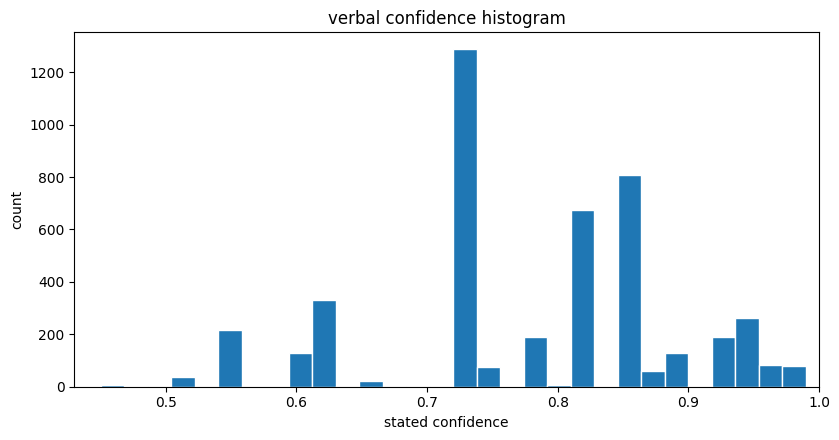

In [7]:
calib.plot_histograms(metrics)

In [8]:
calib.value_counts(signals["verbal"][0], scale=SCALE, label="verbal")

verbal: 23 unique stated confidence values
   45:     7
   50:     2
   52:    36
   55:   218
   60:   129
   62:   330
   63:     1
   65:    20
   70:     4
   72:  1288
   75:    76
   78:   191
   80:     7
   82:   676
   85:   809
   88:    60
   90:   130
   91:     1
   92:   188
   95:   263
   97:    82
   98:     8
   99:    70


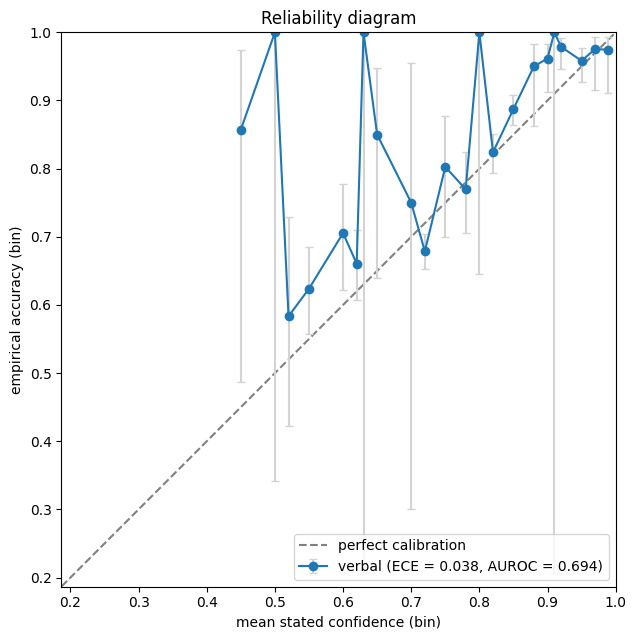

In [9]:
calib.plot_reliability(metrics)